Analysis of the aggregated cell survival data
- With classic LQ fit
- With unweighted Rorvik

In [1]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import statsmodels.api as sm
from scipy.optimize import curve_fit
from scipy.optimize import fsolve
from sklearn.metrics import r2_score

CHANGE THESE: the relevant folder and file paths

In [2]:
#enter list of paths to results folders here
results_folders = [r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Archived - Autumn 2025 with old protocol\EXP_2025_10_16", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Archived - Autumn 2025 with old protocol\EXP_2025_10_30", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Archived - Autumn 2025 with old protocol\EXP_2025_11_18", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\EXP_2026_2_4", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\EXP_2026_2_26", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\EXP_2026_3_2", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\EXP_2026_3_11", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\EXP_2026_3_18", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\EXP_2026_3_19"]

#enter list of multiplicity file paths here
multi_x = [r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Archived - Autumn 2025 with old protocol\Multiplicity X-ray 16-10.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Archived - Autumn 2025 with old protocol\Multiplicity X-ray 30-10.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Archived - Autumn 2025 with old protocol\Multiplicity X-ray 18-11.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\2026_2_4\Multiplicity X-ray 4-2.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\2026_2_26\Multiplicity X-ray 26-2.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\2026_3_2\Multiplicity X-rays 2-3.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\2026_3_11\Multiplicity X-rays 11-3.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\2026_3_18\Multiplicity X-ray 18-3.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\2026_3_19\Multiplicity X-ray 19-3.xlsx"]
multi_p = [r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Archived - Autumn 2025 with old protocol\Multiplicity proton 16-10.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Archived - Autumn 2025 with old protocol\Multiplicity proton 30-10.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Archived - Autumn 2025 with old protocol\Multiplicity proton 18-11.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\2026_2_4\Multiplicity protons 4-2.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\2026_2_26\Multiplicity protons 26-2.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\2026_3_2\Multiplicity protons 2-3.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\2026_3_11\Multiplicity X-rays 11-3.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\2026_3_18\Multiplicity proton 18-3.xlsx", r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\2026_3_19\Multiplicity proton 19-3.xlsx"]


Loading and importing data.

In [3]:
def write_fractions_dic(path):
    data = pd.read_excel(path)
    total = np.array(data['Total'])[-1]

    fractions_dic = {}

    for column in data.items():
        if column[0] != 'Sample' and column[0] != 'Total': #ignore first and last column
            size = column[0]
            count = np.array(column[1])[-1]
            frac = count/total

            fractions_dic[size] = frac

    return fractions_dic

In [4]:
def cfu_survival_func(s, dic, SF):
    sum = 0
    for key, frac in dic.items():
        power = np.power((1-s),int(key))
        sum += frac*(1-power)
    
    #subtract the SF to use root
    sum -= SF
    return sum

In [5]:
def Parse_data(input, exp, fractions_dic):
    #Split colony counting data into cell survival for each sample
    #The survival is calculated for each triplicate separately and normalised to control
    #Also write LET to output for Rorvik calculations

    #inputs:
    #input = dataframe with the dose, plated cells and count of each triplicate for each sample, Format [Dose Plated Count1 Count2 Count3]

    #outputs:
    #output = dataframe with survival per triplicate and LET, Format [Dose LET Survival]

    def write_LET(rad_type):
        if rad_type == 'X':
            return 2.02
        if rad_type == 'Proton L':
            return 1.3
        if rad_type == 'Proton M':
            return 10.1
        if rad_type == 'Proton H':
            return 16.5

    triplicates_control = ["Count_1", "Count_2", "Count_3","Count_4", "Count_5", "Count_6"]

    #Isolate controls, calculate control survival for normalising
    control_data = input[input['Dose'] == 0]
    control_survival = control_data[triplicates_control].mean(axis=1)/control_data['Plated']

    #Write data to output with dose and survival
    output = pd.DataFrame(columns=['Dose', 'LET', 'Survival'])

    #Loop through rows of input to process data and write to output.
    #Each triplicate is processed separately
    for row in input.itertuples():
        newrow = {}
        newrow['Dose'] = row.Dose
        survival = (row.Count_1/row.Plated)/control_survival
        newrow['SF'] = float(survival.iloc[0])
        newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
        newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
        newrow['Experiment'] = exp
        output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

        newrow = {}
        newrow['Dose'] = row.Dose
        survival = (row.Count_2/row.Plated)/control_survival
        newrow['SF'] = float(survival.iloc[0])
        newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
        newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
        newrow['Experiment'] = exp
        output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

        newrow = {}
        newrow['Dose'] = row.Dose
        survival = (row.Count_3/row.Plated)/control_survival
        newrow['SF'] = float(survival.iloc[0])
        newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
        newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
        newrow['Experiment'] = exp
        output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

        if row.Dose == 0:
            newrow = {}
            newrow['Dose'] = row.Dose
            survival = (row.Count_4/row.Plated)/control_survival
            newrow['SF'] = float(survival.iloc[0])
            newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
            newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
            newrow['Experiment'] = exp
            output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

            newrow = {}
            newrow['Dose'] = row.Dose
            survival = (row.Count_5/row.Plated)/control_survival
            newrow['SF'] = float(survival.iloc[0])
            newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
            newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
            newrow['Experiment'] = exp
            output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

            newrow = {}
            newrow['Dose'] = row.Dose
            survival = (row.Count_6/row.Plated)/control_survival
            newrow['SF'] = float(survival.iloc[0])
            newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
            newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
            newrow['Experiment'] = exp
            output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

    return output

In [6]:
#Load and process data

#Loop through folders to extract all excels and write to dataframes
X = pd.DataFrame(columns=['Dose', 'LET', 'SF', 'Survival', 'Experiment'])
PL = pd.DataFrame(columns=['Dose', 'LET', 'SF', 'Survival', 'Experiment'])
PM = pd.DataFrame(columns=['Dose', 'LET', 'SF', 'Survival', 'Experiment'])
PH = pd.DataFrame(columns=['Dose', 'LET', 'SF', 'Survival', 'Experiment'])

for i in range(len(results_folders)):
    folder = results_folders[i]
    experi = os.path.split(folder)[-1]
    multiplicity_x = write_fractions_dic(multi_x[i])
    multiplicity_p = write_fractions_dic(multi_p[i])
    for file in os.listdir(folder):
        if os.path.splitext(os.path.join(folder, file))[-1] == '.xlsx':
            #Read in if it's an excel file
            df = pd.read_excel(os.path.join(folder, file), index_col=None)

            #Check the radiation type and write to correct dataframe
            if df.tail(1)['Rad'].item() == 'X':
                data = Parse_data(df, experi, multiplicity_x)
                #Correct X-ray dose
                data['Dose'] = 0.85*data['Dose'] 
                if i!=2:
                    #Exclude exp 3
                    X = pd.concat([X, data])   
            if df.tail(1)['Rad'].item() == 'Proton L':
                data = Parse_data(df, experi, multiplicity_p)
                data['Dose'] = data['Dose']
                PL = pd.concat([PL, data])
            if df.tail(1)['Rad'].item() == 'Proton H':
                data = Parse_data(df, experi, multiplicity_p)
                data['Dose'] = data['Dose']
                PH = pd.concat([PH, data])
            if df.tail(1)['Rad'].item() == 'Proton M':
                data = Parse_data(df, experi, multiplicity_p)
                data['Dose'] = data['Dose']
                PM = pd.concat([PM, data])



C:\Users\bhaan\AppData\Local\Temp\ipykernel_31180\1460020481.py:38: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, newrow['SF']))[0]
C:\Users\bhaan\AppData\Local\Temp\ipykernel_31180\1460020481.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)
C:\Users\bhaan\AppData\Local\Temp\ipykernel_31180\1460020481.py:66: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  newrow['Survival'] = fsolve(cfu_survival_func, 0.2, args=(fractions_dic, new

# Perform LQ fit on data

In [7]:
def Process_data(input):
    #Process [Dose Survival] data per sample into a mean and std per triplicate

    #inputs
    #df = dataframe [Dose Survival Experiment] per sample as outputted by the cell loading the data

    #output
    #df_means = dataframe ['Dose' 'Mean Survival' 'Experiment] per triplicate
    #df_stds = standard deviation of log of survival per triplicate

    #copy the input for processing
    df = input.copy()
    dose_levels = np.unique(df['Dose'])

    df_means_total = pd.DataFrame(columns=['Dose', 'Mean Survival', 'STD', 'Experiment'])

    for exp in np.unique(df['Experiment']):
        data = df[df['Experiment']==exp]

        #Process into mean and std per triplicate
        df_means = pd.DataFrame(columns=['Dose', 'Mean Survival', 'STD', 'Experiment'])

        for i in range(len(dose_levels)):
            dose = dose_levels[i]
            
            #Select triplicate
            trip = data[data['Dose']==dose]
            newrow = {}

            #Write dose
            newrow['Dose'] = dose
            newrow['Experiment'] = trip['Experiment'].iloc[0]

            #Calculate mean, ignoring any NaN values
            newrow['Mean Survival'] = np.nanmean(np.array(trip['Survival']))
            #Write standard dev
            newrow['STD'] = np.nanstd(np.array(trip['Survival']))
            df_means = pd.concat([df_means, pd.DataFrame([newrow])])


        #Re-normalise with multiplicities
        df_means['Mean Survival'] = df_means['Mean Survival']/df_means['Mean Survival'].iloc[0] 

        df_means_total = pd.concat([df_means_total, df_means])   

    return df_means_total 

In [8]:
def Perform_LQ_fit(sample):
    #Generate LQ fit

    #inputs:
    #sample = dataframe as ['Dose' 'Mean Survival'] for all triplicates, as outputted by 'Process_data'

    #returns:
    #params = np array containing the two LQ fit parameters
    #LQ function handle for use in further calculations

    def Function(d, a, b):
        return np.exp(-(a*d + b*(np.square(d))))

    x = np.array(sample['Dose'], dtype='float')
    y = np.array(sample['Mean Survival'], dtype = 'float')

    p0 = (0.1, 0.1)

    popt, pcov = curve_fit(Function, x, y, p0=p0, bounds=(0,1))
    
    return popt

In [9]:
def LQ_func(d, a, b):
        return np.exp(-(a*d + b*(np.square(d))))

In [10]:
#Process data into means and standard devs for all
X_means = Process_data(X) 
PL_means = Process_data(PL)
PH_means = Process_data(PH)
PM_means = Process_data(PM)

#Dose uncertainties
#X-ray dose uncertainty obtained from the experiments with Michel as described in my notebook on 2/12/2025
X_dose_err = pd.DataFrame({'Dose':X_means['Dose'], 'Err': 0.071*X_means['Dose'], 'Exp': X_means['Experiment']})
#Proton dose uncertainties obtained from dosimetry, as described in dosimetry final
PL_dose_err = pd.DataFrame({'Dose':PL_means['Dose'], 'Err': 0.029*PL_means['Dose'], 'Exp': PL_means['Experiment']})
PH_dose_err = pd.DataFrame({'Dose':PH_means['Dose'], 'Err': 0.038*PH_means['Dose'], 'Exp': PH_means['Experiment']})

#Assume mid LET position dose uncertainty to be the same as low LET
PM_dose_err = pd.DataFrame({'Dose':PL_means['Dose'], 'Err': 0.029*PL_means['Dose'], 'Exp': PL_means['Experiment']})


C:\Users\bhaan\AppData\Local\Temp\ipykernel_31180\1333535518.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_means = pd.concat([df_means, pd.DataFrame([newrow])])
C:\Users\bhaan\AppData\Local\Temp\ipykernel_31180\1333535518.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_means_total = pd.concat([df_means_total, df_means])
C:\Users\bhaan\AppData\Local\Temp\ipykernel_31180\1333535518.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is depre

# X-rays, all data

In [11]:
#LQ fit X-rays

params_x = Perform_LQ_fit(X_means)

true = X_means['Mean Survival']
pred = LQ_func(np.array(X_means['Dose'], dtype=float), params_x[0], params_x[1])
r2_x = r2_score(np.log10(true), np.log10(pred))


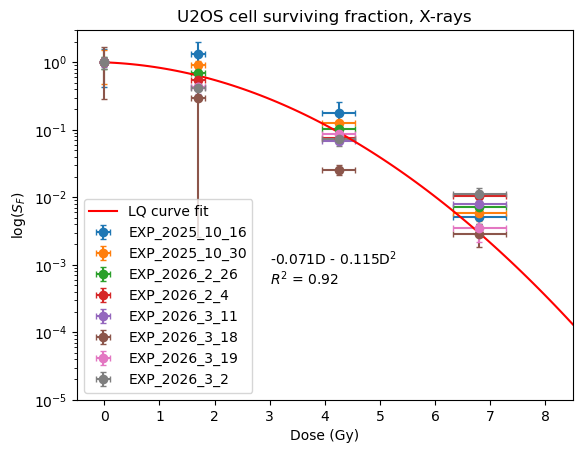

In [12]:
#Plot X-rays
#plot per experiment
for i in range(len(np.unique(np.array(X_means['Experiment'])))):
    exp = np.unique(np.array(X_means['Experiment']))[i]
    data = X_means[X_means['Experiment']==exp]
    error = np.array(data['STD'])
    dose_error = X_dose_err[X_dose_err['Exp']==exp]
    plt.errorbar(data['Dose'], data['Mean Survival'], yerr=error, xerr=dose_error['Err'], fmt='o', capsize=2, label=exp)
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_x[0], params_x[1]), color='r', label='LQ curve fit')
plt.title('U2OS cell surviving fraction, X-rays')
plt.text(3, 0.001, f"-{round(params_x[0],3)}D - {round(params_x[1],3)}D$^2$")
plt.text(3, 0.0005, f"$R^2$ = {round(r2_x, 2)}")
plt.xlim([-0.5, 8.5])
plt.ylim([0.00001, 3])
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.yscale('log')
plt.legend()

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_31180\948827593.py:15: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(np.unique(X_means['Dose']), -2*sigmas, label='2$\sigma$', ls='--', color='r')


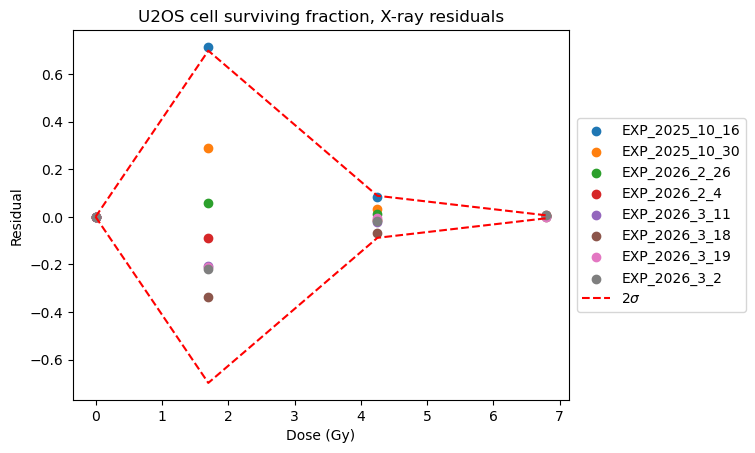

In [13]:
#Calculate residuals
for i in range(len(np.unique(np.array(X_means['Experiment'])))):
    exp = np.unique(np.array(X_means['Experiment']))[i]
    data = X_means[X_means['Experiment']==exp]
    pred = LQ_func(data['Dose'], params_x[0], params_x[1])
    plt.scatter(data['Dose'], (data['Mean Survival'] - pred), label=exp)

#calculate standard dev per dose level
sigmas = []
for d in np.unique(X_means['Dose']):
    doselevel_data = X_means[X_means['Dose']==d]
    sigmas = np.append(sigmas, doselevel_data['Mean Survival'].std())

plt.plot(np.unique(X_means['Dose']), 2*sigmas, ls='--', color='r')
plt.plot(np.unique(X_means['Dose']), -2*sigmas, label='2$\sigma$', ls='--', color='r')
plt.title('U2OS cell surviving fraction, X-ray residuals')
plt.xlabel('Dose (Gy)')
plt.ylabel('Residual')
plt.legend(loc="center right", bbox_to_anchor=(1.37,0.5))

# X-rays, excluding outliers

In [14]:
#Copy original
X_means_OG = X_means

#Drop experiments that should be excluded
X_means = X_means[(X_means['Experiment']!= 'EXP_2025_10_16')]
X_means = X_means[(X_means['Experiment']!= 'EXP_2026_3_18')]

In [15]:
#LQ fit X-rays

params_x = Perform_LQ_fit(X_means)

true = X_means['Mean Survival']
pred = LQ_func(np.array(X_means['Dose'], dtype=float), params_x[0], params_x[1])
r2_x = r2_score(np.log10(true), np.log10(pred))

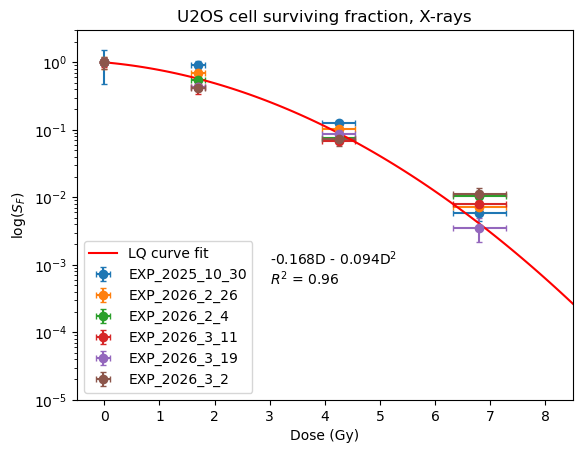

In [16]:
#Plot X-rays
#plot per experiment
for i in range(len(np.unique(np.array(X_means['Experiment'])))):
    exp = np.unique(np.array(X_means['Experiment']))[i]
    data = X_means[X_means['Experiment']==exp]
    error = np.array(data['STD'])
    dose_error = X_dose_err[X_dose_err['Exp']==exp]
    plt.errorbar(data['Dose'], data['Mean Survival'], yerr=error, xerr=dose_error['Err'], fmt='o', capsize=2, label=exp)
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_x[0], params_x[1]), color='r', label='LQ curve fit')
plt.title('U2OS cell surviving fraction, X-rays')
plt.text(3, 0.001, f"-{round(params_x[0],3)}D - {round(params_x[1],3)}D$^2$")
plt.text(3, 0.0005, f"$R^2$ = {round(r2_x, 3)}")
plt.xlim([-0.5, 8.5])
plt.ylim([0.00001, 3])
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.yscale('log')
plt.legend()

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_31180\948827593.py:15: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(np.unique(X_means['Dose']), -2*sigmas, label='2$\sigma$', ls='--', color='r')


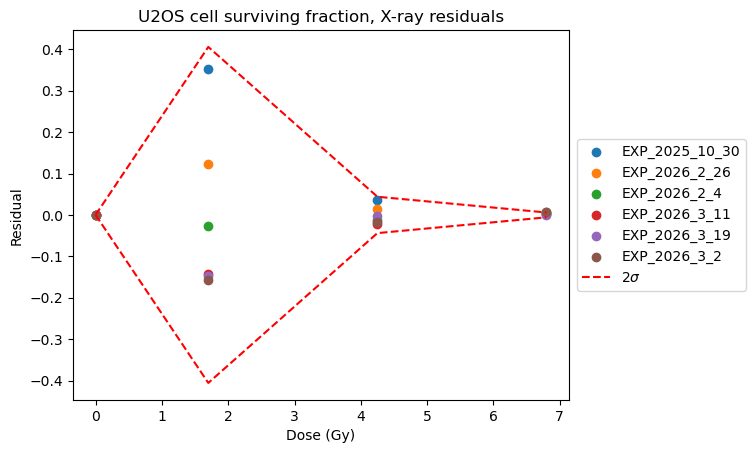

In [17]:
#Calculate residuals
for i in range(len(np.unique(np.array(X_means['Experiment'])))):
    exp = np.unique(np.array(X_means['Experiment']))[i]
    data = X_means[X_means['Experiment']==exp]
    pred = LQ_func(data['Dose'], params_x[0], params_x[1])
    plt.scatter(data['Dose'], (data['Mean Survival'] - pred), label=exp)

#calculate standard dev per dose level
sigmas = []
for d in np.unique(X_means['Dose']):
    doselevel_data = X_means[X_means['Dose']==d]
    sigmas = np.append(sigmas, doselevel_data['Mean Survival'].std())

plt.plot(np.unique(X_means['Dose']), 2*sigmas, ls='--', color='r')
plt.plot(np.unique(X_means['Dose']), -2*sigmas, label='2$\sigma$', ls='--', color='r')
plt.title('U2OS cell surviving fraction, X-ray residuals')
plt.xlabel('Dose (Gy)')
plt.ylabel('Residual')
plt.legend(loc="center right", bbox_to_anchor=(1.37,0.5))

# Protons low, all data

In [18]:
#LQ fit proton low

params_pl = Perform_LQ_fit(PL_means)

true = PL_means['Mean Survival']
pred = LQ_func(np.array(PL_means['Dose'], dtype=float), params_pl[0], params_pl[1])

r2_pl = r2_score(np.log10(true), np.log10(pred))

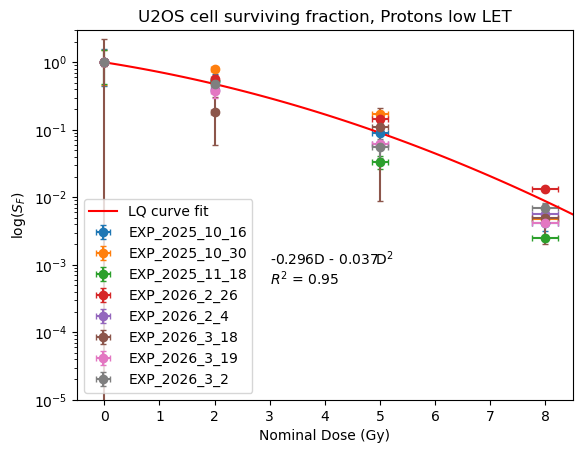

In [19]:
#Plot protons low
for i in range(len(np.unique(np.array(PL_means['Experiment'])))):
    exp = np.unique(np.array(PL_means['Experiment']))[i]
    data = PL_means[PL_means['Experiment']==exp]
    error = np.array(data['STD'])
    dose_error = PL_dose_err[PL_dose_err['Exp']==exp]
    plt.errorbar(data['Dose'], data['Mean Survival'], yerr=error, xerr=dose_error['Err'], fmt='o', capsize=2, label=exp)
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_pl[0], params_pl[1]), color='r', label='LQ curve fit')
plt.title('U2OS cell surviving fraction, Protons low LET')
plt.text(3, 0.001, f"-{round(params_pl[0],3)}D - {round(params_pl[1],3)}D$^2$")
plt.text(3, 0.0005, f"$R^2$ = {round(r2_pl, 2)}")
plt.xlim([-0.5, 8.5])
plt.ylim([0.00001, 3])
plt.xlabel('Nominal Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.yscale('log')
plt.legend()

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_31180\3185206202.py:15: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(np.unique(PL_means['Dose']), -2*sigmas, label='2$\sigma$', ls='--', color='r')


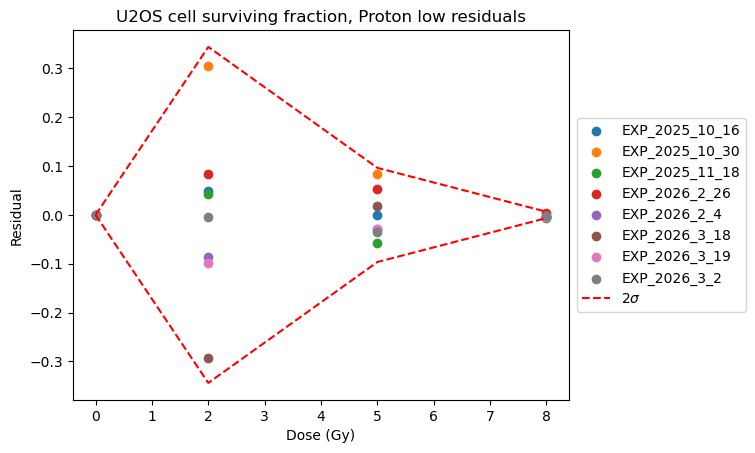

In [20]:
#Calculate residuals
for i in range(len(np.unique(np.array(PL_means['Experiment'])))):
    exp = np.unique(np.array(PL_means['Experiment']))[i]
    data = PL_means[PL_means['Experiment']==exp]
    pred = LQ_func(np.array(data['Dose']).astype(float), params_pl[0], params_pl[1])
    plt.scatter(data['Dose'], (data['Mean Survival'] - pred), label=exp)

#calculate standard dev per dose level
sigmas = []
for d in np.unique(PL_means['Dose']):
    doselevel_data = PL_means[PL_means['Dose']==d]
    sigmas = np.append(sigmas, doselevel_data['Mean Survival'].std())

plt.plot(np.unique(PL_means['Dose']), 2*sigmas, ls='--', color='r')
plt.plot(np.unique(PL_means['Dose']), -2*sigmas, label='2$\sigma$', ls='--', color='r')
plt.title('U2OS cell surviving fraction, Proton low residuals')
plt.xlabel('Dose (Gy)')
plt.ylabel('Residual')
plt.legend(loc="center right", bbox_to_anchor=(1.37,0.5))

# Protons low, excluding outliers

In [21]:
#Copy original
PL_means_OG = PL_means

#Drop experiments that should be excluded
PL_means = PL_means[(PL_means['Experiment']!= 'EXP_2026_3_18')]

In [22]:
#LQ fit proton low

params_pl = Perform_LQ_fit(PL_means)

true = PL_means['Mean Survival']
pred = LQ_func(np.array(PL_means['Dose'], dtype=float), params_pl[0], params_pl[1])

r2_pl = r2_score(np.log10(true), np.log10(pred))

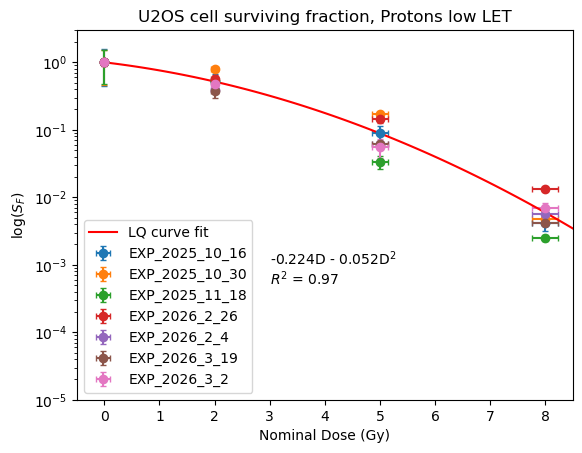

In [23]:
#Plot protons low
for i in range(len(np.unique(np.array(PL_means['Experiment'])))):
    exp = np.unique(np.array(PL_means['Experiment']))[i]
    data = PL_means[PL_means['Experiment']==exp]
    error = np.array(data['STD'])
    dose_error = PL_dose_err[PL_dose_err['Exp']==exp]
    plt.errorbar(data['Dose'], data['Mean Survival'], yerr=error, xerr=dose_error['Err'], fmt='o', capsize=2, label=exp)
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_pl[0], params_pl[1]), color='r', label='LQ curve fit')
plt.title('U2OS cell surviving fraction, Protons low LET')
plt.text(3, 0.001, f"-{round(params_pl[0],3)}D - {round(params_pl[1],3)}D$^2$")
plt.text(3, 0.0005, f"$R^2$ = {round(r2_pl, 2)}")
plt.xlim([-0.5, 8.5])
plt.ylim([0.00001, 3])
plt.xlabel('Nominal Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.yscale('log')
plt.legend()

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_31180\3185206202.py:15: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(np.unique(PL_means['Dose']), -2*sigmas, label='2$\sigma$', ls='--', color='r')


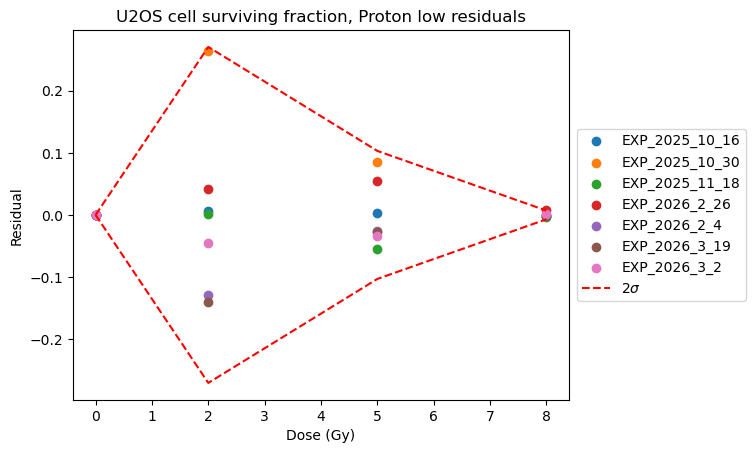

In [24]:
#Calculate residuals
for i in range(len(np.unique(np.array(PL_means['Experiment'])))):
    exp = np.unique(np.array(PL_means['Experiment']))[i]
    data = PL_means[PL_means['Experiment']==exp]
    pred = LQ_func(np.array(data['Dose']).astype(float), params_pl[0], params_pl[1])
    plt.scatter(data['Dose'], (data['Mean Survival'] - pred), label=exp)

#calculate standard dev per dose level
sigmas = []
for d in np.unique(PL_means['Dose']):
    doselevel_data = PL_means[PL_means['Dose']==d]
    sigmas = np.append(sigmas, doselevel_data['Mean Survival'].std())

plt.plot(np.unique(PL_means['Dose']), 2*sigmas, ls='--', color='r')
plt.plot(np.unique(PL_means['Dose']), -2*sigmas, label='2$\sigma$', ls='--', color='r')
plt.title('U2OS cell surviving fraction, Proton low residuals')
plt.xlabel('Dose (Gy)')
plt.ylabel('Residual')
plt.legend(loc="center right", bbox_to_anchor=(1.37,0.5))

# Proton high, all data

In [25]:
#LQ fit proton high

params_ph = Perform_LQ_fit(PH_means)

true = PH_means['Mean Survival']
pred = LQ_func(np.array(PH_means['Dose'], dtype=float), params_ph[0], params_ph[1])

r2_ph = r2_score(np.log10(true), np.log10(pred)) 

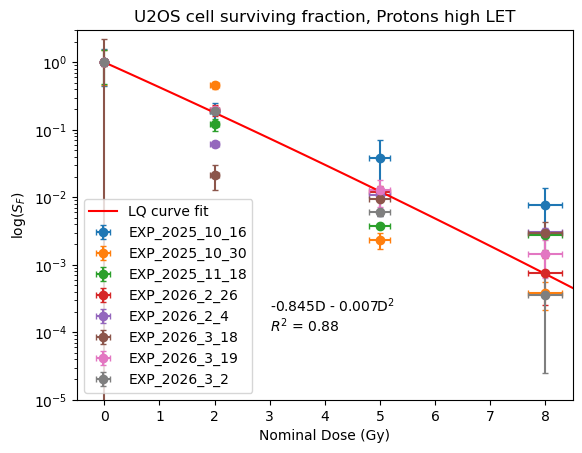

In [26]:
#Plot Protons High
for i in range(len(np.unique(np.array(PH_means['Experiment'])))):
    exp = np.unique(np.array(PH_means['Experiment']))[i]
    data = PH_means[PH_means['Experiment']==exp]
    error = np.array(data['STD'])
    dose_error = PH_dose_err[PH_dose_err['Exp']== exp]
    plt.errorbar(data['Dose'], data['Mean Survival'], yerr=error, xerr=dose_error['Err'], fmt='o', capsize=2, label=exp)
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_ph[0], params_ph[1]), color='r', label='LQ curve fit')
plt.title('U2OS cell surviving fraction, Protons high LET')
plt.text(3, 2e-4, f"-{round(params_ph[0],3)}D - {round(params_ph[1],3)}D$^2$")
plt.text(3, 10e-5, f"$R^2$ = {round(r2_ph, 2)}")
plt.xlim([-0.5, 8.5])
plt.ylim([0.00001, 3])
plt.xlabel('Nominal Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.yscale('log')
plt.legend()

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_31180\3627782277.py:15: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(np.unique(PH_means['Dose']), -2*sigmas, label='2$\sigma$', ls='--', color='r')


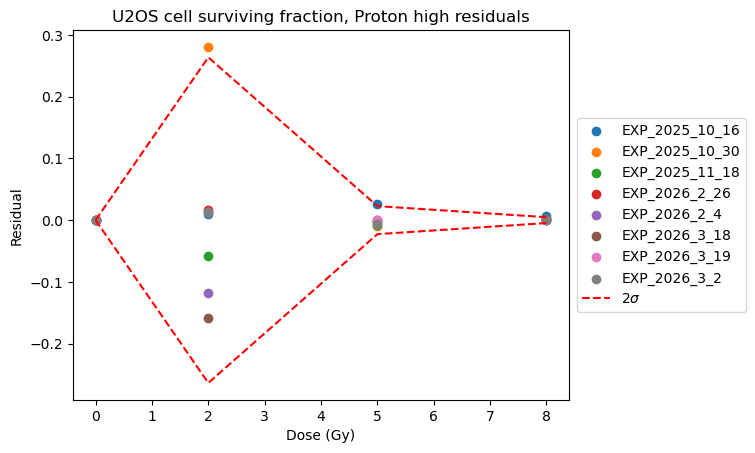

In [27]:
#Calculate residuals
for i in range(len(np.unique(np.array(PH_means['Experiment'])))):
    exp = np.unique(np.array(PH_means['Experiment']))[i]
    data = PH_means[PH_means['Experiment']==exp]
    pred = LQ_func(np.array(data['Dose']).astype(float), params_ph[0], params_ph[1])
    plt.scatter(data['Dose'], (data['Mean Survival'] - pred), label=exp)

#calculate standard dev per dose level
sigmas = []
for d in np.unique(PH_means['Dose']):
    doselevel_data = PH_means[PH_means['Dose']==d]
    sigmas = np.append(sigmas, doselevel_data['Mean Survival'].std())

plt.plot(np.unique(PH_means['Dose']), 2*sigmas, ls='--', color='r')
plt.plot(np.unique(PH_means['Dose']), -2*sigmas, label='2$\sigma$', ls='--', color='r')
plt.title('U2OS cell surviving fraction, Proton high residuals')
plt.xlabel('Dose (Gy)')
plt.ylabel('Residual')
plt.legend(loc="center right", bbox_to_anchor=(1.37,0.5))

# Proton high, excluding outliers

In [28]:
#Copy original
PH_means_OG = PH_means

#Drop experiments that should be excluded
PH_means = PH_means[(PH_means['Experiment']!= 'EXP_2026_3_18')]
PH_means = PH_means[(PH_means['Experiment']!= 'EXP_2025_10_30')]
#PH_means = PH_means[(PH_means['Experiment']!= 'EXP_2025_10_16')] op het randje when refitting --> discuss w. Eirik

In [29]:
#LQ fit proton high

params_ph = Perform_LQ_fit(PH_means)

true = PH_means['Mean Survival']
pred = LQ_func(np.array(PH_means['Dose'], dtype=float), params_ph[0], params_ph[1])

r2_ph = r2_score(np.log10(true), np.log10(pred)) 

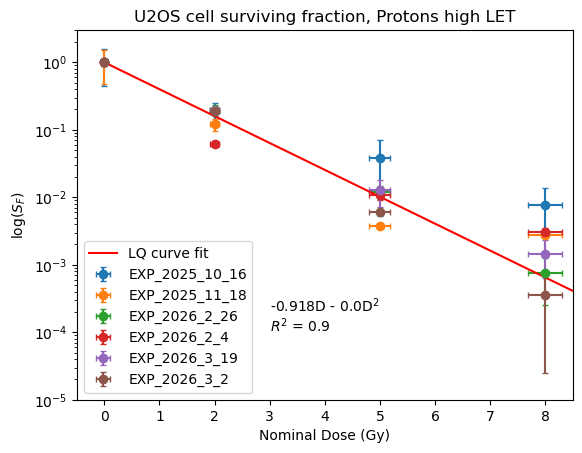

In [30]:
#Plot Protons High
for i in range(len(np.unique(np.array(PH_means['Experiment'])))):
    exp = np.unique(np.array(PH_means['Experiment']))[i]
    data = PH_means[PH_means['Experiment']==exp]
    error = np.array(data['STD'])
    dose_error = PH_dose_err[PH_dose_err['Exp']== exp]
    plt.errorbar(data['Dose'], data['Mean Survival'], yerr=error, xerr=dose_error['Err'], fmt='o', capsize=2, label=exp)
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_ph[0], params_ph[1]), color='r', label='LQ curve fit')
plt.title('U2OS cell surviving fraction, Protons high LET')
plt.text(3, 2e-4, f"-{round(params_ph[0],3)}D - {round(params_ph[1],3)}D$^2$")
plt.text(3, 10e-5, f"$R^2$ = {round(r2_ph, 2)}")
plt.xlim([-0.5, 8.5])
plt.ylim([0.00001, 3])
plt.xlabel('Nominal Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.yscale('log')
plt.legend()

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_31180\3627782277.py:15: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(np.unique(PH_means['Dose']), -2*sigmas, label='2$\sigma$', ls='--', color='r')


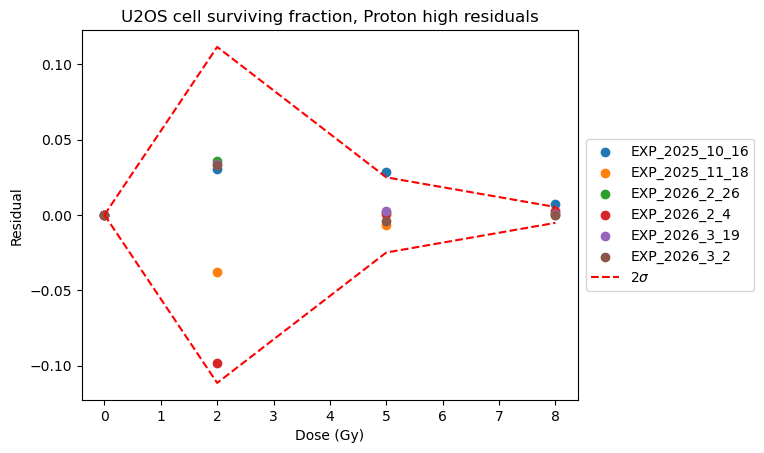

In [31]:
#Calculate residuals
for i in range(len(np.unique(np.array(PH_means['Experiment'])))):
    exp = np.unique(np.array(PH_means['Experiment']))[i]
    data = PH_means[PH_means['Experiment']==exp]
    pred = LQ_func(np.array(data['Dose']).astype(float), params_ph[0], params_ph[1])
    plt.scatter(data['Dose'], (data['Mean Survival'] - pred), label=exp)

#calculate standard dev per dose level
sigmas = []
for d in np.unique(PH_means['Dose']):
    doselevel_data = PH_means[PH_means['Dose']==d]
    sigmas = np.append(sigmas, doselevel_data['Mean Survival'].std())

plt.plot(np.unique(PH_means['Dose']), 2*sigmas, ls='--', color='r')
plt.plot(np.unique(PH_means['Dose']), -2*sigmas, label='2$\sigma$', ls='--', color='r')
plt.title('U2OS cell surviving fraction, Proton high residuals')
plt.xlabel('Dose (Gy)')
plt.ylabel('Residual')
plt.legend(loc="center right", bbox_to_anchor=(1.37,0.5))

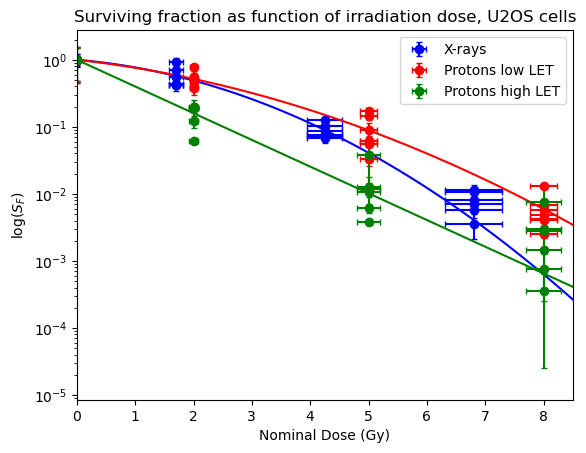

In [32]:
#re-do dose errors
#Dose uncertainties
#X-ray dose uncertainty obtained from the experiments with Michel as described in my notebook on 2/12/2025
X_dose_err = pd.DataFrame({'Dose':X_means['Dose'], 'Err': 0.071*X_means['Dose'], 'Exp': X_means['Experiment']})
#Proton dose uncertainties obtained from dosimetry, as described in dosimetry final
PL_dose_err = pd.DataFrame({'Dose':PL_means['Dose'], 'Err': 0.029*PL_means['Dose'], 'Exp': PL_means['Experiment']})
PH_dose_err = pd.DataFrame({'Dose':PH_means['Dose'], 'Err': 0.038*PH_means['Dose'], 'Exp': PH_means['Experiment']})

#Plot them all together
plt.errorbar(X_means['Dose'], X_means['Mean Survival'], yerr=X_means['STD'], xerr=X_dose_err['Err'], label='X-rays', color='b', fmt='o', capsize=2)
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_x[0], params_x[1]), color='b')

plt.errorbar(PL_means['Dose'], PL_means['Mean Survival'], yerr=PL_means['STD'], xerr=PL_dose_err['Err'], label='Protons low LET', color='r', fmt='o', capsize=2)
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_pl[0], params_pl[1]), color='r')

plt.errorbar(PH_means['Dose'], PH_means['Mean Survival'], yerr=PH_means['STD'], xerr=PH_dose_err['Err'], label='Protons high LET', color='g', fmt='o', capsize=2)
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_ph[0], params_ph[1]), color='g')

plt.title('Surviving fraction as function of irradiation dose, U2OS cells')
plt.xlim([0, 8.5])
plt.xlabel('Nominal Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.yscale('log')
plt.legend()

# Rørvik fit

In [33]:
def R_Func(X, a, b, c):
    d, l, dtwo = X
    return np.exp(-(a*d + b*l + c*dtwo))

In [34]:
def Rorvik_fit_scipy(sample):
    #inputs:
    #sample = dataframe as ['Dose' 'Mean Survival'] for all triplicates, as outputted by 'Process_data'

    #returns:
    #params = np array containing the two LQ fit parameters
    #LQ function handle for use in further calculations

    def Function(X, a, b, c):
        d, l, dtwo = X
        return np.exp(-(a*d + b*l + c*dtwo))

    dose = np.array(sample['Dose'], dtype='float')
    let = np.array(sample['LET'], dtype = 'float')
    X= (dose, dose*let, np.square(dose))

    y = np.array(sample['Survival'], dtype = 'float')

    p0 = (0.1, 0.1, 0.1)

    popt, pcov = curve_fit(Function, X, y, p0=p0, bounds=(0,1))
    
    return popt

In [35]:
#Take copies
X_rorvik = X.copy()
PL_rorvik = PL.copy()
PH_rorvik = PH.copy()

#Remove any zero survivals
X_rorvik = X_rorvik[X_rorvik['SF']!=0]
PL_rorvik = PL_rorvik[PL_rorvik['SF']!=0]
PH_rorvik = PH_rorvik[PH_rorvik['SF']!=0]

#Remove 8 Gy
PL_rorvik = PL_rorvik[PL_rorvik['Dose']!=8]
PH_rorvik = PH_rorvik[PH_rorvik['Dose']!=8]

#Drop the required experiments from X
X_rorvik = X_rorvik[X_rorvik['Experiment'] != 'EXP_2026_3_18']
X_rorvik = X_rorvik[X_rorvik['Experiment'] != 'EXP_2025_10_16']

#Drop the required experiments from PL
PL_rorvik = PL_rorvik[PL_rorvik['Experiment'] != 'EXP_2026_3_18']

#Drop the required experiments from X
PH_rorvik = PH_rorvik[PH_rorvik['Experiment'] != 'EXP_2026_3_18']
PH_rorvik = PH_rorvik[PH_rorvik['Experiment'] != 'EXP_2025_10_30']

#Remove NaN
X_rorvik.dropna(inplace=True, subset=['SF'])
PL_rorvik.dropna(inplace=True, subset=['SF'])
PH_rorvik.dropna(inplace=True, subset=['SF'])

#Aggregate data back into one dataframe
total_data = pd.concat([X_rorvik, PL_rorvik, PH_rorvik])

#Fit curve scipy
params = Rorvik_fit_scipy(total_data)
params_rorvik = params
print(params)

print('a/b ratio: ' + str(params[0]/params[2]))

[0.24087246 0.03719687 0.05692815]
a/b ratio: 4.231166108964851


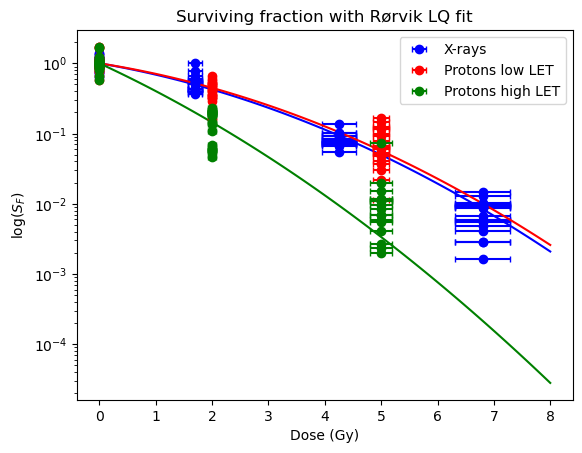

In [36]:
#Plot data
d = np.linspace(0,8,100)

let = X_rorvik.iloc[0]['LET']
x = (d, d*let, np.square(d))
y_x = R_Func(x, params[0], params[1], params[2])
plt.errorbar(X_rorvik['Dose'], X_rorvik['Survival'], xerr=0.071*X_rorvik['Dose'], label='X-rays', color='blue', fmt='o', capsize=2)
plt.plot(d, y_x, color='blue')

let = PL_rorvik.iloc[0]['LET']
x = (d, d*let, np.square(d))
y_pl = R_Func(x, params[0], params[1], params[2])
plt.errorbar(PL_rorvik['Dose'], PL_rorvik['Survival'], xerr=0.029*PL_rorvik['Dose'], label='Protons low LET', fmt='o', color='red', capsize=2)
plt.plot(d, y_pl, color='red')

let = PH_rorvik.iloc[0]['LET']
x = (d, d*let, np.square(d))
y_ph = R_Func(x, params[0], params[1], params[2])
plt.errorbar(PH_rorvik['Dose'], PH_rorvik['Survival'], xerr=0.038*PH_rorvik['Dose'], label='Protons high LET', fmt='o', color='green', capsize=2)
plt.plot(d, y_ph, color='green')

#Customise
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.title('Surviving fraction with Rørvik LQ fit')
plt.legend()
plt.yscale('log')

Attempt to implement RBE model according to Rorvik

<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_31180\601217156.py:21: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel('LET (keV/$\mu$m)')


Text(0.5, 0.92, 'RBE as function of dose and LET, Rørvik')

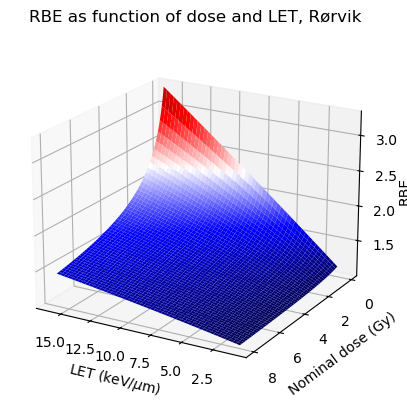

In [54]:
letvals = np.linspace(1, 16, 1000)
dosevals = np.linspace(0.1, 8, 1000)
letvals, dosevals = np.meshgrid(letvals, dosevals)

a_x = params[0]
b_x = params[2]
k = params[1]

RBEmin = 1
RBEmax = 1 + (k/a_x)*letvals
A_B = a_x/b_x

squareterm = np.square(A_B) + 4*dosevals*A_B*RBEmax + 4*np.square(dosevals)*np.square(RBEmin)
RBE = (1/(2*dosevals))*(np.sqrt(squareterm) - A_B)

fig = plt.figure()

ax1 = fig.add_subplot(1, 1, 1, projection='3d')
ax1.view_init(elev=20, azim=120, roll=0)
ax1.plot_surface(letvals, dosevals, RBE, cmap = 'seismic', vmin=1, vmax=3.5)
ax1.set_xlabel('LET (keV/$\mu$m)')
ax1.set_ylabel('Nominal dose (Gy)')
ax1.set_zlabel('RBE', rotation=90)
ax1.zaxis.labelpad=-0.8 
ax1.set_title('RBE as function of dose and LET, Rørvik')


<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_31180\2742880828.py:2: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('LET (keV/$\mu$m)')


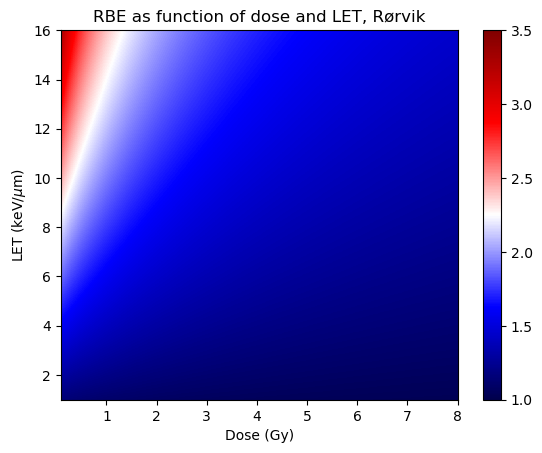

In [53]:
plt.pcolormesh(dosevals, letvals, RBE, cmap='seismic', vmin=1, vmax=3.5)
plt.ylabel('LET (keV/$\mu$m)')
plt.xlabel('Dose (Gy)')
plt.title('RBE as function of dose and LET, Rørvik')
plt.colorbar()

# Mid LET prediction from Rorvik

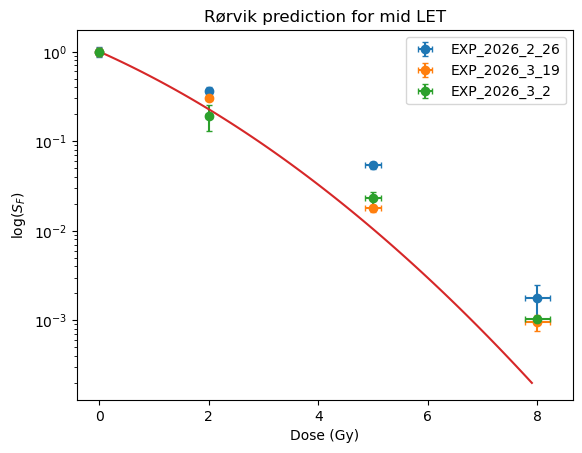

In [50]:
dosevals = np.arange(0, 8, 0.1)
mid_let = 10.1 #kev/um

pred_survival = R_Func((dosevals, dosevals*mid_let, np.square(dosevals)), params[0], params[1], params[2])

#Drop 18/3
PM_means = PM_means[PM_means['Experiment']!='EXP_2026_3_18']

#Plot Protons Mid experiment data
for i in range(len(np.unique(np.array(PM_means['Experiment'])))):
    exp = np.unique(np.array(PM_means['Experiment']))[i]
    data = PM_means[PM_means['Experiment']==exp]
    error = np.array(data['STD'])
    dose_error = PM_dose_err[PM_dose_err['Exp']== exp]
    plt.errorbar(data['Dose'], data['Mean Survival'], yerr=error, xerr=dose_error['Err'], fmt='o', capsize=2, label=exp)

plt.plot(dosevals, pred_survival)
plt.yscale('log')
plt.title('Rørvik prediction for mid LET')
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.legend()

# Generic RBE value for protons

In [40]:
from scipy.interpolate import interp1d

sv_rbe = 0.37

interp_x = interp1d(y_x, d)
D_x = interp_x(sv_rbe)

interp_pl = interp1d(y_pl, d)
D_pl = interp_pl(sv_rbe)

interp_ph = interp1d(y_ph, d)
D_ph = interp_ph(sv_rbe)

RBE_pl = D_x/D_pl
print('RBE proton low: ' + str(round(RBE_pl,2)))

RBE_ph = D_x/D_ph
print('RBE proton high: ' + str(round(RBE_ph,2)))


RBE proton low: 0.95
RBE proton high: 2.06


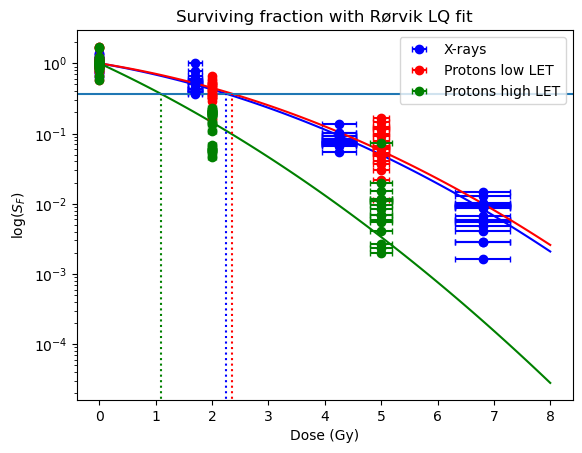

In [41]:
#Plot data with the RBE stuff
d = np.linspace(0,8,100)

let = X_rorvik.iloc[0]['LET']
x = (d, d*let, np.square(d))
y_x = R_Func(x, params[0], params[1], params[2])
plt.errorbar(X_rorvik['Dose'], X_rorvik['Survival'], xerr=0.071*X_rorvik['Dose'], label='X-rays', color='blue', fmt='o', capsize=2)
plt.plot(d, y_x, color='blue')

let = PL_rorvik.iloc[0]['LET']
x = (d, d*let, np.square(d))
y_pl = R_Func(x, params[0], params[1], params[2])
plt.errorbar(PL_rorvik['Dose'], PL_rorvik['Survival'], xerr=0.029*PL_rorvik['Dose'], label='Protons low LET', fmt='o', color='red', capsize=2)
plt.plot(d, y_pl, color='red')

let = PH_rorvik.iloc[0]['LET']
x = (d, d*let, np.square(d))
y_ph = R_Func(x, params[0], params[1], params[2])
plt.errorbar(PH_rorvik['Dose'], PH_rorvik['Survival'], xerr=0.038*PH_rorvik['Dose'], label='Protons high LET', fmt='o', color='green', capsize=2)
plt.plot(d, y_ph, color='green')

#Add RBE info
plt.hlines(sv_rbe, -2, 10)
plt.vlines(D_x, 0, sv_rbe, colors='blue', linestyles='dotted')
plt.vlines(D_pl, 0, sv_rbe, colors='red', linestyles='dotted')
plt.vlines(D_ph, 0, sv_rbe, colors='green', linestyles='dotted')

#Customise
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.xlim([-0.4, 8.4])
plt.title('Surviving fraction with Rørvik LQ fit')
plt.legend()
plt.yscale('log')

# Bootstrap uncertainty analysis for RBE fit

In [42]:
def Calculate_RBE(d, let, p):

    if d == 0:
        RBE[i] = 1

    else:
        a_x = p[0]
        b_x = p[2]
        k = p[1]

        RBEmin = 1
        RBEmax = 1 + (k/a_x)*let
        A_B = a_x/b_x

        squareterm = np.square(A_B) + 4*d*A_B*RBEmax + 4*np.square(d)*np.square(RBEmin)
        RBE = (1/(2*d))*(np.sqrt(squareterm) - A_B)

    return RBE

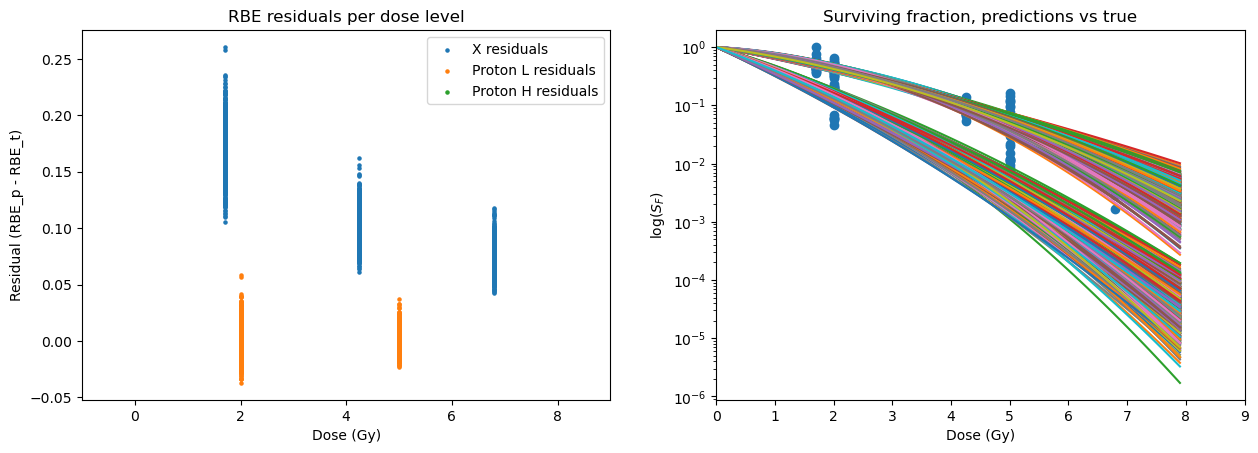

In [43]:
total_data = total_data[total_data['Dose'] != 0]
#Sample size
n_sample = len(total_data)
#number of bootstrap samples
n_bootstraps = 1000

Residuals_x = np.array([])
Residuals_pl = np.array([])
Residuals_ph = np.array([])
Bootstrap_doses_x = np.array([])
Bootstrap_doses_pl = np.array([])
Bootstrap_doses_ph = np.array([])

#prepare figures
figure, axis = plt.subplots(1,2)
axis[1].scatter(total_data['Dose'], total_data['Survival'], label="True")
figure.set_figwidth(15)

bs = 0
while bs < n_bootstraps:
    #Resample the data into a bootstrap sample (so with replacement)
    indices = np.random.randint(0, n_sample, n_sample) #randomly generate indexes
    
    #resample data
    Doses_b = total_data['Dose'].iloc[indices]
    let_b = total_data['LET'].iloc[indices]
    survival_b = total_data['Survival'].iloc[indices]

    #refit parameters
    total_b = pd.concat([Doses_b, let_b, survival_b], axis=1)
    total_b.sort_values(by='Dose', inplace=True, ascending=True)
    params = Rorvik_fit_scipy(total_b)

    #calculate resulting RBE and residual for each dose/let combo
    let_vals = np.unique(let_b)
    for let in let_vals:
        dos = total_data[total_data['LET'] == let]
        dose_vals = np.unique(dos['Dose'])
        for dose in dose_vals:
            rbe = Calculate_RBE(dose, let, params)

            if rbe > 2.0:
                continue

            #Calculate residual
            if let == 2.02:
                residual = rbe - 1
                Residuals_x = np.append(Residuals_x, np.array(residual))
                Bootstrap_doses_x = np.append(Bootstrap_doses_x, np.array(dose))
            if let == 1.30:
                residual = rbe - Calculate_RBE(dose, let, params_rorvik)
                Residuals_pl = np.append(Residuals_pl, np.array(residual))
                Bootstrap_doses_pl = np.append(Bootstrap_doses_pl, np.array(dose))
            if let == 16.0:
                residual = rbe - Calculate_RBE(dose, let, params_rorvik)
                Residuals_ph = np.append(Residuals_ph, np.array(residual))
                Bootstrap_doses_ph = np.append(Bootstrap_doses_ph, np.array(dose))

            #print('RBE: ' + str(rbe) + ', LET: ' + str(let), ', Dose: ' + str(dose))

    #Plot prediction vs data for each dose level
    for let in let_vals:
        d = np.arange(0, 8, 0.1)
        dat = (d, let*d, np.square(d))
        axis[1].plot(d, R_Func(np.array(dat).astype(float), params[0], params[1], params[2]), label=str(bs))

    bs += 1
    
#Plot residuals for each dose level
axis[0].scatter(Bootstrap_doses_x, Residuals_x, s=5, label='X residuals')
axis[0].scatter(Bootstrap_doses_pl, Residuals_pl, s=5, label='Proton L residuals')
axis[0].scatter(Bootstrap_doses_ph, Residuals_ph, s=5, label='Proton H residuals')

#Customise residual plot
axis[0].set_xlabel("Dose (Gy)")
axis[0].set_ylabel("Residual (RBE_p - RBE_t)")
axis[0].set_title("RBE residuals per dose level")
axis[0].set_xlim([-1, 9])
axis[0].legend()
# axis[0].legend(loc="center right")

#Customise prediction plot
axis[1].set_xlabel("Dose (Gy)")
axis[1].set_ylabel('log($S_F$)')
axis[1].set_title("Surviving fraction, predictions vs true")
axis[1].set_xlim([0, 9])
axis[1].set_yscale('log')
# axis[1].legend(loc="center right")


Text(0, 0.5, 'Count')

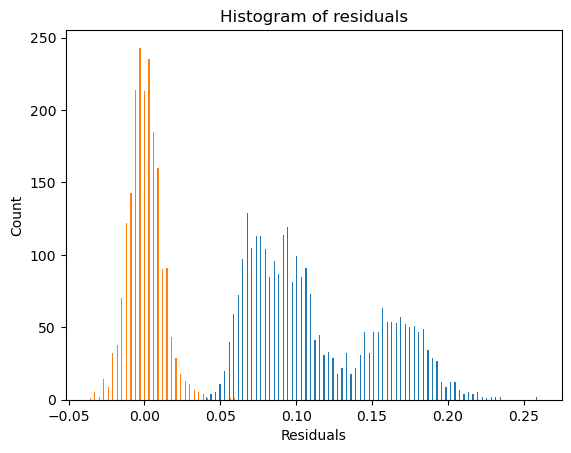

In [44]:
#Make residuals data into a 1D array, sorted smallest to largest
for Res in (Residuals_x, Residuals_pl, Residuals_ph):
    Res = Res.reshape(-1)
    index = np.argsort(Res)
    Res = np.array([Res[i] for i in index])

plt.title("Histogram of residuals")
plt.hist([Residuals_x, Residuals_pl, Residuals_ph], bins=100, label=['X-rays', 'Proton low', 'Proton high'])
plt.xlabel("Residuals")
plt.ylabel("Count")

In [45]:
#Iteratively loop through uncertainty values until 95% of residual data lies within these values
Res = np.concatenate([Residuals_x, Residuals_pl, Residuals_ph])
Res = Res.reshape(-1)
index = np.argsort(Res)
Res = np.array([Res[i] for i in index])
uncertainty_values = np.arange(0.01, 1, 0.01)

for u in uncertainty_values:
    #Find residual values within the range -u to u
    locs = np.where((Res > -u) & (Res < u))

    #Divide by total number of residuals to find percentage
    percentage = len(locs[0])/len(Res)

    #Once 95 percent is reached, break out of loop
    if percentage > 0.95:
        break

#Print data
print("Uncertainty value: \u00B1" + str(round(u,2)))
print("Percentage of data within these bounds: " + str(round(percentage*100,1)) + "%")

Uncertainty value: ±0.19
Percentage of data within these bounds: 97.4%


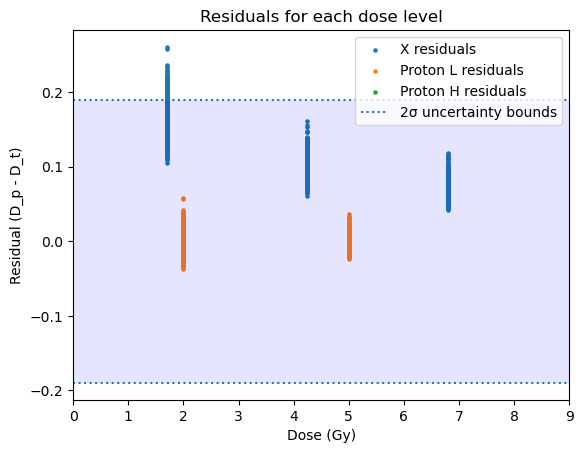

In [46]:
#Replot residuals with uncertainty bounds
plt.scatter(Bootstrap_doses_x, Residuals_x, s=5, label='X residuals')
plt.scatter(Bootstrap_doses_pl, Residuals_pl, s=5, label='Proton L residuals')
plt.scatter(Bootstrap_doses_ph, Residuals_ph, s=5, label='Proton H residuals')
plt.xlabel("Dose (Gy)")
plt.ylabel("Residual (D_p - D_t)")
plt.title("Residuals for each dose level")
plt.xlim([0, 9])
plt.axhline(u, linestyle=":", label="2\u03C3 uncertainty bounds")
plt.axhline(-u, linestyle=":")
plt.axhspan(-u, u, facecolor='blue', alpha=0.1)
plt.legend()